# **Predicting recidivism**
Explainable AI final assignment

Lize van der Gulden -- S1097659

## **Documentation**

### **Project overview**
Compare DiCE counterfactual explanations and SHAP feature-attribution explanations to identify actionable, intervention-relevant factors for reducing recidivism risk using a Random Forest model trained on a recidivism dataset.

**Dataset**: recidivism_full.csv

**Target**: Recidivism_Within_3years (binary)

**Train/test split**: 80/20 stratified by target (random_state=42)

**Model**: RandomForestClassifier (n_estimators=200, random_state=42) inside a sklearn Pipeline after preprocessing

### **Code steps**
1.	Environment & libraries
2.	Load data, define X and y, split data into train and test set
3.	Random Forest Classifier
    -   Transform data so categorical and numeric columns can both be used.
    -   Train RF.
    -   Evaluate.
    -   Retreive and plot feature importances.
4.	Define immutable, mutable and policy-actionable features.
5.	Code to generate DiCE counterfactual explanations.
    1. Setup DiCE
    2. Generate CF to see if it works.
6.	Code to compute SHAP explanations.
    1. Apply TreeExplainer to the trained RandomForest
    2. Compute SHAP values for instance and plot waterfall plots to see if it works.
7.  Quantitavely compare DiCE and SHAP on coverage and actionability
8.  Show DiCE and SHAP for several instances to compare qualitatively




### **Quantitative Evaluation**
Sampling: up to N_SAMPLES (default 200) test instances evaluated.

For each instance:
1. Generate constrained DiCE counterfactuals (features_to_vary=mutable, total_CFs=5).
2. Compute SHAP aggregated top-K features (SHAP_TOP_K=5) and measure actionable overlap.

Metrics reported:
1. Mutable feature coverage: proportion of instances where at least one mutable feature appears in the explanation (DiCE: constrained counterfactual with mutable feature exists; SHAP: top-5 includes at least one mutable).

2. Actionability coverage: proportion of instances where at least one actionable feature appears in the explanation (DiCE: constrained counterfactual with actionable feature exists; SHAP: top-5 includes at least one actionable).

3. Average number of actionable features per instance.

The method assumes interventions on policy_actionable features are feasible in practice; domain experts should validate.

### **Instance Evaluation**
Compare output of SHAP and CF for a number of instances on how clear and useful they would be for officers.

## 1. Environment & libraries

In [ ]:
# Install missing packages and import libs (run once)
import sys
import subprocess
import pkg_resources

required = {
    'scikit-learn': 'sklearn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'shap': 'shap',
    'dice-ml': 'dice_ml',
    'plotly': 'plotly',
    'scipy': 'scipy',
    'tqdm': 'tqdm',
    'seaborn': 'seaborn'
}

pip_map = {
    'sklearn': 'scikit-learn',
    'dice_ml': 'dice-ml'
}

def install_pkg(pkg_name):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])

# Install missing packages
installed = {pkg.key for pkg in pkg_resources.working_set}
for pip_name, import_name in required.items():
    pkg_key = pip_name.lower()
    if pip_map.get(import_name):
        pkg_key = pip_map[import_name].lower()
    if pkg_key not in installed:
        print(f"Installing {pip_name}...")
        install_pkg(pip_name)

Installing dice-ml...


In [ ]:
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import shap
import dice_ml
from dice_ml import Dice
import plotly.express as px
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import tqdm
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import seaborn as sns
import random

## 2. Load data

In [ ]:
# -----------------------------
# DATA LOADING & INITIAL INSPECTION
# -----------------------------

# Load the dataset.
# Ensure the file "recidivism_full.csv" is present in the working directory or provide a full path.
df = pd.read_csv("recidivism_full.csv")

# Inspect data
cols = df.columns.tolist()
print(len(cols), cols)

# Show proportion of missing values per column
print(df.isna().mean().sort_values(ascending=False).head(30))

54 ['ID', 'Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Risk_Score_First', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_PPViolationCharges', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Conviction_Episodes_PPViolationCharges', 'Prior_Conviction_Episodes_DomesticViolenceCharges', 'Prior_Conviction_Episodes_GunCharges', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport',

In [ ]:
# -----------------------------
# PREPROCESSING
# -----------------------------

# Drop identifier and redundant targets.
df = df.drop(columns=['ID'], errors='ignore')
df = df.drop(columns=['Recidivism_Arrest_Year1'], errors='ignore')
df = df.drop(columns=['Recidivism_Arrest_Year2'], errors='ignore')
df = df.drop(columns=['Recidivism_Arrest_Year3'], errors='ignore')
df = df.drop(columns=['Training_Sample'], errors='ignore')
cols = df.columns.tolist()

# Define target variable and feature matrix.
# Cast the target to integer to ensure compatibility with classifiers that expect discrete labels.
X = df.drop(['Recidivism_Within_3years'],axis=1)
y = df['Recidivism_Within_3years'].astype(int)

# Define numeric collumns
numeric_cols = [
    'Avg_Days_per_DrugTest', 'DrugTests_THC_Positive', 'DrugTests_Cocaine_Positive', 'DrugTests_Meth_Positive',
    'DrugTests_Other_Positive', 'Jobs_Per_Year', 'Supervision_Risk_Score_First', 'Percent_Days_Employed']

# Define categorical collumns as all other collumns
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric:", numeric_cols[:15])
print("Categorical:", categorical_cols)

# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Numeric: ['Avg_Days_per_DrugTest', 'DrugTests_THC_Positive', 'DrugTests_Cocaine_Positive', 'DrugTests_Meth_Positive', 'DrugTests_Other_Positive', 'Jobs_Per_Year', 'Supervision_Risk_Score_First', 'Percent_Days_Employed']
Categorical: ['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_PPViolationCharges', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Conviction_Episodes_PPViolationCharges', 'Prior_Conviction_Episodes_DomesticViolenceCharges', 'Prior_Conviction_Episodes_GunCharges', 'Prior_Revoc

## 3. Random Forest

In [ ]:
# -----------------------------
# TRAIN RANDOM FOREST MODEL
# -----------------------------

# Transformers for preprocessing numeric and categorical features before modeling.
# Numeric pipeline:
#  - Impute missing numeric values with the median.
#  - Scale numeric features to zero mean and unit variance.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline:
#  - Impute missing categorical values with the most frequent category.
#  - One-hot encode categories; ignore unknown categories at transform time.
#    sparse_output=False returns a dense array (compatible with later steps).
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer to apply the appropriate pipeline to each column group.
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# pipeline with RandomForest
rf_pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# train RandomForest on data
rf_pipeline.fit(X_train, y_train)

# Predict class labels and probabilities on the test set.
y_pred = rf_pipeline.predict(X_test)
probs = rf_pipeline.predict_proba(X_test)[:,1]

# Evaluate performance: accuracy and AUC (ROC).
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("AUC:", round(roc_auc_score(y_test, probs), 3))

Accuracy: 0.724
AUC: 0.784


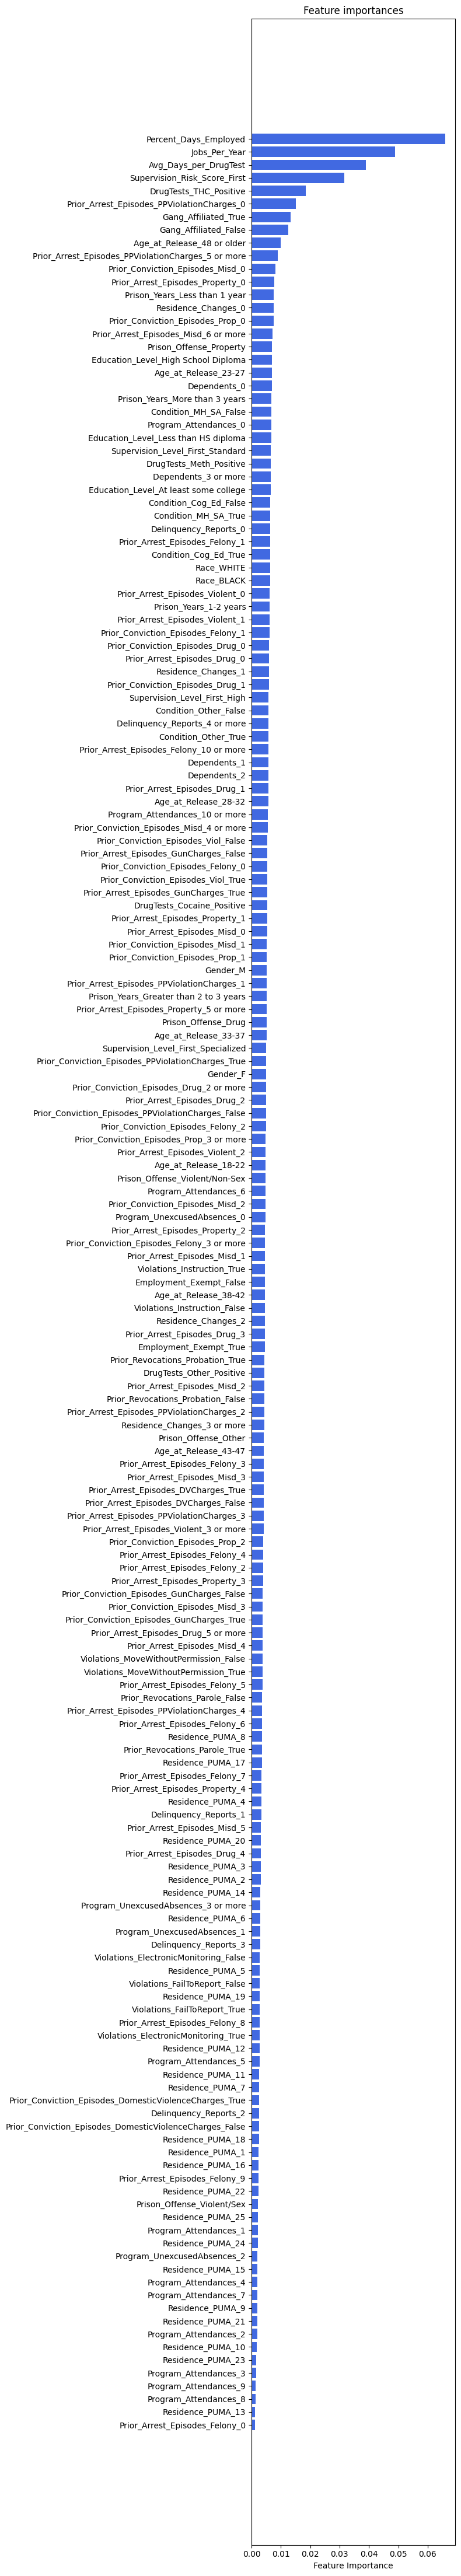

In [ ]:
# -----------------------------
# EXTRACT & PLOT FEATURE IMPORTANCES
# -----------------------------

# Access trained RandomForest classifier and preprocessing step from the pipeline.
clf = rf_pipeline.named_steps['clf']
pre = rf_pipeline.named_steps['pre']

# Build the feature name list in the same order as the transformed feature matrix:
importances = clf.feature_importances_
feature_names = []

# numeric columns are added as-is
feature_names.extend(numeric_cols)

# categorical columns are one-hot encoded
cat_transformer = pre.named_transformers_['cat']
onehot = cat_transformer.named_steps['onehot']
cat_feature_names = onehot.get_feature_names_out(categorical_cols)
feature_names.extend(cat_feature_names.tolist())

# plot feature importances
idx = np.argsort(importances)
plt.figure(figsize=(8, max(4, 0.25*len(feature_names))))
plt.barh(np.array(feature_names)[idx], importances[idx], color='royalblue')
plt.xlabel('Feature Importance')
plt.title('Feature importances')
plt.tight_layout()
plt.show()

## 4. Define immutable and mutable features.

In [ ]:
# Immutable features: features that should not be changed in counterfactuals.
immutable = [
 'Gender','Race','Age_at_Release','Prison_Offense','Prison_Years',
 'Prior_Arrest_Episodes_Felony','Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent',
 'Prior_Arrest_Episodes_Property','Prior_Arrest_Episodes_Drug','Prior_Arrest_Episodes_PPViolationCharges',
 'Prior_Arrest_Episodes_DVCharges','Prior_Arrest_Episodes_GunCharges',
 'Prior_Conviction_Episodes_Felony','Prior_Conviction_Episodes_Misd','Prior_Conviction_Episodes_Viol',
 'Prior_Conviction_Episodes_Prop','Prior_Conviction_Episodes_Drug','Prior_Conviction_Episodes_PPViolationCharges',
 'Prior_Conviction_Episodes_DomesticViolenceCharges','Prior_Conviction_Episodes_GunCharges',
 'Prior_Revocations_Parole','Prior_Revocations_Probation'
]

# Everything else is treated mutable
mutable = [c for c in X.columns if c not in immutable]

# The following columns are policy actionable
policy_actionable = [
 'Education_Level','Program_Attendances','Program_UnexcusedAbsences','Percent_Days_Employed',
 'Jobs_Per_Year','Supervision_Level_First','Supervision_Risk_Score_First',
 'Condition_MH_SA','Condition_Cog_Ed','DrugTests_THC_Positive','DrugTests_Cocaine_Positive',
 'DrugTests_Meth_Positive','DrugTests_Other_Positive'
]

## 5. Generate DiCE counterfactual explanations.

In [ ]:
# -----------------------------
# DICE SETUP
# -----------------------------

# Wrap the sklearn pipeline so DiCE can call predict_proba on raw dataframes.
class SklearnModelWrapper:
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def predict_proba(self, input_df):
        # Ensure the pipeline receives columns in the same order it was trained on.
        return self.pipeline.predict_proba(input_df)

# Create a DiCE Data object using training data (X_train + y_train).
# Specify continuous_features so DiCE knows which columns are numeric.
d = dice_ml.Data(dataframe=pd.concat([X_train, y_train], axis=1),
                 continuous_features=numeric_cols,
                 outcome_name='Recidivism_Within_3years')

# Create a DiCE Model object using the sklearn wrapper.
m = dice_ml.Model(model=SklearnModelWrapper(rf_pipeline), backend='sklearn')
dice_obj = Dice(d, m)

In [ ]:
# -----------------------------
# COUNTERFACTUAL GENERATION
# -----------------------------

# Select a single test instance to generate counterfactuals for (first row of X_test).
xi = X_test.iloc[[0]].copy()

# Fit imputers on training data concatenated with xi so that xi is imputed using training statistics.
num_imputer = SimpleImputer(strategy='median')
xi.loc[:, numeric_cols] = num_imputer.fit_transform(
    pd.concat([X_train[numeric_cols], xi[numeric_cols]], axis=0)
)[-len(xi):]

cat_imputer = SimpleImputer(strategy='most_frequent')
xi.loc[:, categorical_cols] = cat_imputer.fit_transform(
    pd.concat([X_train[categorical_cols], xi[categorical_cols]], axis=0)
)[-len(xi):]

# Unconstrained CFs: allow any changes.
cf_unconstrained = dice_obj.generate_counterfactuals(
    xi,
    total_CFs=5,
    desired_class="opposite"
)

# Constrained CFs: only allow changes to features listed in mutable
cf_constrained = dice_obj.generate_counterfactuals(
    xi,
    total_CFs=5,
    desired_class="opposite",
    features_to_vary=mutable
)

# Constrained Policy Actionable CFs: only allow changes to features listed in policy_actionable
cf_constrained_act = dice_obj.generate_counterfactuals(
    xi,
    total_CFs=5,
    desired_class="opposite",
    features_to_vary=policy_actionable
)

# Display results where possible; handle API differences across DiCE versions.
try:
    print("Unconstrained CFs:")
    display(cf_unconstrained.visualize_as_dataframe())
    print("Constrained CFs:")
    display(cf_constrained.visualize_as_dataframe())
    print("Constrained actionable CFs:")
    display(cf_constrained_act.visualize_as_dataframe())
except Exception:
    # fallback: print object
    print(cf_unconstrained)
    print(cf_constrained)

100%|██████████| 1/1 [00:05<00:00,  5.31s/it]

Unconstrained CFs:
Query instance (original outcome : 1)


,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,...,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,37.285713,0.285714,0.0,0.0,0.0,0.321839,1.0,True,1



Diverse Counterfactual set (new outcome: 0)


,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,...,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,773.600000,0.100000,0.0,0.0,0.0,1.1,1.0,False,0
1,M,BLACK,43-47,10,False,4.0,High,High School Diploma,2,Property,...,0,37.285714,0.285714,0.0,0.0,0.6,0.9,0.2,False,0
2,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,37.285714,0.285714,0.0,0.0,0.0,1.1,0.1,False,0
3,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,37.285714,0.285714,0.0,0.0,0.0,1.1,0.1,False,0
4,M,BLACK,48 or older,10,False,4.0,Standard,High School Diploma,2,Property,...,0,997.000000,0.285714,0.0,0.0,0.0,1.0,1.0,True,0


...

Constrained actionable CFs:
Query instance (original outcome : 1)


,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,...,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,37.285713,0.285714,0.0,0.0,0.0,0.321839,1.0,True,1



Diverse Counterfactual set (new outcome: 0)


,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,...,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,M,BLACK,43-47,10,False,4.0,Standard,High School Diploma,2,Property,...,0,37.285714,0.7,0.0,0.0,0.0,0.9,0.2,False,0
1,M,BLACK,43-47,10,False,3.1,Standard,High School Diploma,2,Property,...,0,37.285714,0.7,0.0,0.0,0.0,0.9,0.2,False,0
2,M,BLACK,43-47,10,False,3.1,Standard,High School Diploma,2,Property,...,0,37.285714,0.7,0.0,0.0,0.0,0.9,0.2,False,0
3,M,BLACK,43-47,10,False,3.1,Standard,Less than HS diploma,2,Property,...,0,37.285714,0.7,0.0,0.0,0.0,0.9,0.2,False,0


None

## 6. Compute SHAP explanations.

In [ ]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------

# Helper: minimal per-row cleaning to match preprocessor
def clean_row(df_row):
    r = df_row.copy()
    for c in categorical_cols:
        if c in r: r[c] = r[c].astype("string").fillna("").astype(str)
    for c in numeric_cols:
        if c in r: r[c] = pd.to_numeric(r[c], errors="coerce").fillna(X_train[c].median())
    return r

# Helper: aggregate one-hot SHAPs back to parent categorical feature
def aggregate_shap_values(shap_vals_array):
    arr1d = np.asarray(shap_vals_array)[0, :, 1]   # assumes (1, n_features, 2)

    df = pd.DataFrame({'feature': feature_names, 'shap_value': arr1d})
    # aggregate numeric and one-hot categorical back to parent categorical features
    rows = []
    for n in numeric_cols:
        if n in df['feature'].values:
            rows.append({'feature': n, 'shap': float(df.loc[df['feature']==n,'shap_value'].iloc[0])})
    for cat in categorical_cols:
        mask = df['feature'].str.startswith(cat + '_')
        if mask.any():
            rows.append({'feature': cat, 'shap': float(df.loc[mask,'shap_value'].sum())})
    return pd.DataFrame(rows).sort_values('shap', key=lambda x: x.abs(), ascending=False).reset_index(drop=True)

In [ ]:
# -----------------------------
# Build feature names and SHAP explainer
# -----------------------------

# Extract preprocessor and classifier from your pipeline
pre = rf_pipeline.named_steps['pre']
clf = rf_pipeline.named_steps['clf']

# Build transformed feature names (numeric then one-hot names)
ohe = pre.named_transformers_['cat'].named_steps['onehot']
ohe_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = list(numeric_cols) + ohe_names

# Clean training set (minimal) and transform for TreeExplainer background
X_train_clean = X_train.copy()
for c in categorical_cols:
    if c in X_train_clean: X_train_clean[c] = X_train_clean[c].astype("string").fillna("").astype(str)
for c in numeric_cols:
    if c in X_train_clean: X_train_clean[c] = pd.to_numeric(X_train_clean[c], errors="coerce").fillna(X_train[c].median())

X_train_trans = pre.transform(X_train_clean)
X_train_trans_df = pd.DataFrame(X_train_trans, columns=feature_names)

# Build TreeExplainer on the fitted RandomForest (fast & exact)
explainer = shap.TreeExplainer(clf, data=X_train_trans_df, feature_perturbation="tree_path_dependent")


# Main function: explain a single-row DataFrame (or Series). Returns (prob, shap_df, shap_array)
def explain_instance(df_row):
    row = clean_row(df_row).reset_index(drop=True)
    X_trans = pre.transform(row)                         # transformed array (1, n_features)
    prob = clf.predict_proba(X_trans)[:, 1][0]           # uncalibrated prob for class 1
    # shap_values returns array (n_rows, n_features) for single-output TreeExplainer
    shap_vals = explainer.shap_values(X_trans)
    # TreeExplainer for binary often returns list [neg, pos]; handle both cases
    if isinstance(shap_vals, list):
        # pick positive-class explanation if available
        sv = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
    else:
        sv = np.asarray(shap_vals)
    sv_row = sv[0] if sv.ndim == 2 else sv  # get 1D array for the single instance
    shap_agg_df = aggregate_shap_values(sv_row)
    return prob, shap_agg_df, sv_row

Selected test index: 48
Predicted probability (uncalibrated): 0.3750


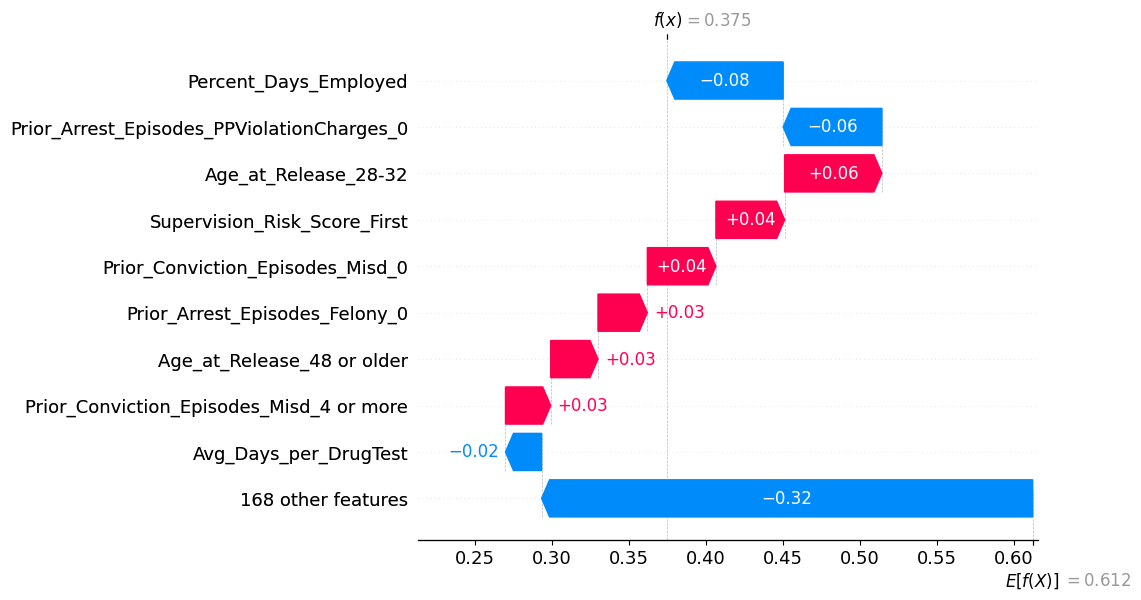

In [ ]:
# -----------------------------
# GENERATE SHAP FOR INSTANCE
# -----------------------------

idx = 48
instance = X_test.reset_index(drop=True).loc[idx:idx]
prob, shap_agg, shap_vals = explain_instance(instance)

shap_vals = np.asarray(shap_vals)[0, :, 1]

print(f"Selected test index: {idx}")
print(f"Predicted probability (uncalibrated): {prob:.4f}")

# Waterfall plot
# get expected value for positive class if available
exp_val = explainer.expected_value[1] if (isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1) else explainer.expected_value
shap.plots._waterfall.waterfall_legacy(exp_val, shap_vals, feature_names=feature_names)


## 7. EVALUATION

In [252]:
# -----------------------------
# QUANTITATIVE EVALUATION
# -----------------------------
# Purpose:
# - Sample a small set of test instances.
# - For each instance, generate constrained DiCE counterfactuals and SHAP values.
# - Count
# - Compute plausibility measures (Mahalanobis, NN distance) and change summaries.
# - Compute SHAP-derived metrics: whether top-K explanations include actionable features,
#   a sparsity measure, and a rough estimated numeric change to achieve a target probability drop.
# -----------------------------

# PARAMETERS
N_SAMPLES = 10  # number of test instances to evaluate (adjustable; <= len(X_test))
CF_PER_INSTANCE = 5
SHAP_TOP_K = 5

In [253]:
# -----------------------------
# SAMPLE INDICES
# -----------------------------

rng = np.random.RandomState(42)
test_idx = X_test.reset_index(drop=True).index.tolist()
if N_SAMPLES < len(test_idx):
    sampled_idx = rng.choice(test_idx, size=N_SAMPLES, replace=False)
else:
    sampled_idx = test_idx

In [254]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------

def prepare_instance_for_dice(inst_df):
    """
    Given a dataframe, impute numeric and categorical fields using imputers fit earlier (num_imputer, cat_imputer), ensuring values match training stats.
    Returns the imputed dataframe ready for DiCE.
    """
    inst = inst_df.copy().reset_index(drop=True)
    # Impute numeric and categorical using training stats (as done earlier)
    inst.loc[:, numeric_cols] = num_imputer.transform(
        pd.concat([X_train[numeric_cols], inst[numeric_cols]], axis=0)
    )[-len(inst):]
    inst.loc[:, categorical_cols] = cat_imputer.transform(
        pd.concat([X_train[categorical_cols], inst[categorical_cols]], axis=0)
    )[-len(inst):]
    return inst

def safe_extract_and_align(cf_obj, target_cols):
    """
    Given a DiCE CF object, attempt to extract a standardized dataframe aligned to target_cols.
    Returns None on failure.
    """
    if cf_obj is None:
        return None
    try:
        df_raw = extract_cf_df_from_dice(cf_obj)
    except Exception:
        return None
    # try to coerce to a DataFrame containing target_cols when available
    df_aligned = df_raw[target_cols].copy()
    # if result is empty, return None
    if df_aligned is None or df_aligned.shape[0] == 0:
        return None
    # Cast numeric columns to numeric where possible
    for c in numeric_cols:
        if c in df_aligned.columns:
            df_aligned[c] = pd.to_numeric(df_aligned[c], errors='coerce')
    return df_aligned.reset_index(drop=True)

def compare_to_original(orig, cf_df):
    """
    For each counterfactual row, compute:
      - which features changed (treat NaNs as equal)
      - counts of changes
      - which immutable and mutable features changed
      - whether only mutable features changed
    Returns a dataframe summarizing these metrics per CF.
    """
    results = []
    for i in range(len(cf_df)):
        cf = cf_df.loc[i, :]
        changed = []
        for c in cols:
            a = orig.loc[0, c]
            b = cf[c]
            # treat nan equal
            if pd.isna(a) and pd.isna(b):
                continue
            if pd.isna(a) != pd.isna(b):
                changed.append(c)
            else:
                # numeric approximate compare
                if c in numeric_cols:
                    try:
                        if float(a) != float(b):
                            changed.append(c)
                    except:
                        if a != b:
                            changed.append(c)
                else:
                    if a != b:
                        changed.append(c)
        num_changes = len(changed)
        imm_changed = [c for c in changed if c in immutable]
        mut_changed = [c for c in changed if c in mutable]
        act_changed = [c for c in changed if c in policy_actionable]
        results.append({
            'cf_index': i,
            'changed_features': changed,
            'num_changes': num_changes,
            'immutable_changed': imm_changed,
            'mutable_changed': mut_changed,
            'actionable_changed': act_changed,
            'only_mutable_changed': len(imm_changed) == 0
        })
    return pd.DataFrame(results)

In [255]:
# -----------------------------
# Recreate DiCE objects tied to training Data/Model for safety
# -----------------------------

dice_data = dice_ml.Data(dataframe=pd.concat([X_train, y_train], axis=1),
                         continuous_features=numeric_cols,
                         outcome_name='Recidivism_Within_3years')
dice_model = dice_ml.Model(model=SklearnModelWrapper(rf_pipeline), backend='sklearn')
dice_obj_global = Dice(dice_data, dice_model)

In [256]:
# -----------------------------
# METRICS ACCUMULATION STRUCTURES
# -----------------------------

# Counters / accumulators
n_total = 0

# Constrained CF stats
cf_coverage_count = 0   # Coverage: amount of instances for which a CF was found
cf_actionable_count = 0     # amount with at least 1 actionable value
cf_sum_actionable_features_avg_per_instance = 0.0  # average total actionable features found per instance
cf_sum_mutable_features_avg_per_instance = 0.0 # average total mutable features found per instance

# SHAP stats
shap_processed_count = 0
shap_coverage_count = 0     # Coverage: number of instances with at least one mutable
shap_actionable_count = 0   # amount with at least 1 actionable value
shap_sum_actionable_features_avg_per_instance = 0.0 # average total actionable features found per instance
shap_sum_mutable_features_avg_per_instance = 0.0 # average total mutable features found per instance

# -----------------------------
# MAIN ITERATION: evaluate sampled instances
# -----------------------------

# FIX: Update the global 'cols' variable to reflect the actual columns in X_train
cols = X_train.columns.tolist()

for idx in tqdm.tqdm(sampled_idx, desc="Evaluating instances"):
    n_total += 1
    inst = X_test.reset_index(drop=True).loc[idx:idx].copy()
    inst_dice = prepare_instance_for_dice(inst)

    # constrained diCE metrics
    try:
        cf_con = dice_obj_global.generate_counterfactuals(inst_dice, desired_class="opposite", features_to_vary=mutable, total_CFs=5)
        df_con = safe_extract_and_align(cf_con, inst.columns.tolist())
    except Exception:
        df_con = None

    if df_con is not None:
        cf_coverage_count += 1 # A constrained CF was found so coverage +1

        stats = compare_to_original(inst.reset_index(drop=True), df_con)

        mut_changed_counts = stats['mutable_changed'].apply(lambda L: len(L) if isinstance(L, (list, tuple)) else 0).values
        cf_sum_mutable_features_avg_per_instance += mut_changed_counts.mean() if len(mut_changed_counts) > 0 else 0.0

        # number of actionable features changed per CF row
        act_changed_counts = stats['actionable_changed'].apply(lambda L: len(L) if isinstance(L, (list, tuple)) else 0).values

        # per-instance average number of actionable features changed across CF rows
        cf_sum_actionable_features_avg_per_instance += act_changed_counts.mean() if len(act_changed_counts) > 0 else 0.0

        if act_changed_counts.sum() > 0:
            cf_actionable_count += 1

        # print("CF changed mutable:", stats['mutable_changed'])
        # print("CF changed actionable:", stats['actionable_changed'])

    # SHAP metrics
    try:
        prob, shap_agg, shap_vals = explain_instance(inst)

        top = shap_agg.head(SHAP_TOP_K)

        n_mut_in_top = len([f for f in top['feature'] if f in mutable])
        shap_sum_mutable_features_avg_per_instance += n_mut_in_top
        if n_mut_in_top > 0:
            shap_coverage_count += 1

        n_act_in_top = len([f for f in top['feature'] if f in policy_actionable])
        shap_sum_actionable_features_avg_per_instance += n_act_in_top
        if n_act_in_top > 0:
            shap_actionable_count += 1

        # print("SHAP top features:", list(shap_agg.head(5)['feature']))
        # print("SHAP actionable in top:", [f for f in shap_agg.head(5)['feature'] if f in policy_actionable])

    except Exception:
        print('Fail')
        pass

Evaluating instances: 100%|██████████| 10/10 [00:30<00:00,  3.09s/it]


In [257]:
# -----------------------------
# AGGREGATE & PRINT RESULTS
# -----------------------------
def pct(count, total):
    return 0.0 if total == 0 else 100.0 * count / total

# Constrained CF variables
cf_amount_possible = cf_coverage_count
cf_amount_possible_pct = pct(cf_coverage_count, n_total)
cf_amount_with_at_least_1_actionable = cf_actionable_count
cf_amount_with_at_least_1_actionable_pct = pct(cf_actionable_count, n_total)
cf_avg_actionable_features_per_found_cf = (cf_sum_actionable_features_avg_per_instance / cf_coverage_count) if cf_coverage_count > 0 else np.nan

# SHAP variables
shap_mutable_coverage_amount = shap_coverage_count
shap_mutable_coverage_pct = pct(shap_coverage_count, n_total)
shap_actionable_coverage_amount = shap_actionable_count
shap_actionable_coverage_pct = pct(shap_actionable_count, n_total) if n_total > 0 else np.nan
shap_avg_actionable_features_in_topk = (shap_sum_actionable_features_avg_per_instance / shap_coverage_count) if shap_coverage_count > 0 else np.nan

# Mutable averages
cf_avg_mutable_per_instance = cf_sum_mutable_features_avg_per_instance / n_total
shap_avg_mutable_in_topK = shap_sum_mutable_features_avg_per_instance / n_total


print("Constrained CF:")
print(f"  Mutable feature coverage: {cf_amount_possible} | {cf_amount_possible_pct:.1f}% of total")
print(f"  Actionability coverage: {cf_amount_with_at_least_1_actionable} | {cf_amount_with_at_least_1_actionable_pct:.1f}% of total")
print(f"  Average number of actionable features (per found CF): {cf_avg_actionable_features_per_found_cf:.3f}")
print(f"  Avg mutable features changed per instance: {cf_avg_mutable_per_instance:.3f}")

print("\nSHAP:")
print(f"  Mutable feature coverage: {shap_mutable_coverage_amount} | {shap_mutable_coverage_pct:.1f}% of total")
print(f"  Actionability coverage: {shap_actionable_coverage_amount} | {shap_actionable_coverage_pct:.1f}% of SHAP-processed")
print(f"  Average number of actionable features (in top-{SHAP_TOP_K}): {shap_avg_actionable_features_in_topk:.3f}")
print(f"  Avg mutable in top-{SHAP_TOP_K} per instance (SHAP): {shap_avg_mutable_in_topK:.3f}")


Constrained CF:
  Mutable feature coverage: 10 | 100.0% of total
  Actionability coverage: 10 | 100.0% of total
  Average number of actionable features (per found CF): 2.720
  Avg mutable features changed per instance: 3.720

SHAP:
  Mutable feature coverage: 10 | 100.0% of total
  Actionability coverage: 9 | 90.0% of SHAP-processed
  Average number of actionable features (in top-5): 1.300
  Avg mutable in top-5 per instance (SHAP): 2.300


## 8. Qualitative evaluation

In [ ]:
def qualitative_report_for_index(idx, show_waterfall=True, max_display_changes=50):
    """
    For a single test instance index:
      - Plot SHAP waterfall (aggregated to original features if shap_agg available)
      - Print/expose a DataFrame listing each CF row and the features that changed with before->after values
    Returns (df_cf, changes_df) where df_cf is aligned CF dataframe (or None) and changes_df lists changes.
    """
    inst = X_test.reset_index(drop=True).loc[idx:idx].copy()

    # SHAP waterfall (aggregated)
    try:
        inst_clean = clean_row(inst)
        inst_trans = pre.transform(inst_clean)
        shap_vals = get_shap_for_transformed(inst_trans)[0]
        shap_df = pd.DataFrame({'feature': feature_names, 'shap_value': shap_vals})
        shap_agg = aggregate_shap(shap_df, numeric_cols, categorical_cols)  # expects ['feature','shap']
        # Use aggregated values for waterfall
        exp_val = explainer.expected_value
        if isinstance(exp_val, (list, np.ndarray)):
            exp_val = exp_val[1] if len(exp_val) > 1 else exp_val[0]
        vals = shap_agg['shap'].values
        feat_names = shap_agg['feature'].tolist()
        # data for Explanation
        data_vals = [inst_clean[f].iloc[0] if f in inst_clean.columns else None for f in feat_names]
        expl = shap.Explanation(values=vals, base_values=exp_val, data=np.array(data_vals), feature_names=feat_names)
        if show_waterfall:
            shap.plots.waterfall(expl)
    except Exception as e:
        print("Could not produce SHAP waterfall:", e)

    # Generate constrained CFs
    try:
        inst_dice = prepare_instance_for_dice(inst)
        cf_con = dice_obj_global.generate_counterfactuals(inst_dice, desired_class="opposite", features_to_vary=mutable,total_CFs=5)
        df_con = safe_extract_and_align(cf_con, inst.columns.tolist())
    except Exception as e:
        df_con = None
        print("diCE constrained CF generation failed:", e)
        return None, None

    stats = compare_to_original(inst.reset_index(drop=True), df_con)

    changes_list = []
    orig = inst.reset_index(drop=True).loc[0]
    for i, row in stats.iterrows():
        cf_row = df_con.loc[row['cf_index']]
        texts = []
        for c in row['changed_features']:
            a = orig[c]
            b = cf_row[c]
            texts.append(f"{c}: {a} -> {b}")
        changes_list.append({'changes_text': "; ".join(texts[:max_display_changes])})

    changes_df = pd.DataFrame(changes_list)
    pd.set_option('display.max_colwidth', None)
    display(changes_df[['changes_text']])

    return df_con, changes_df

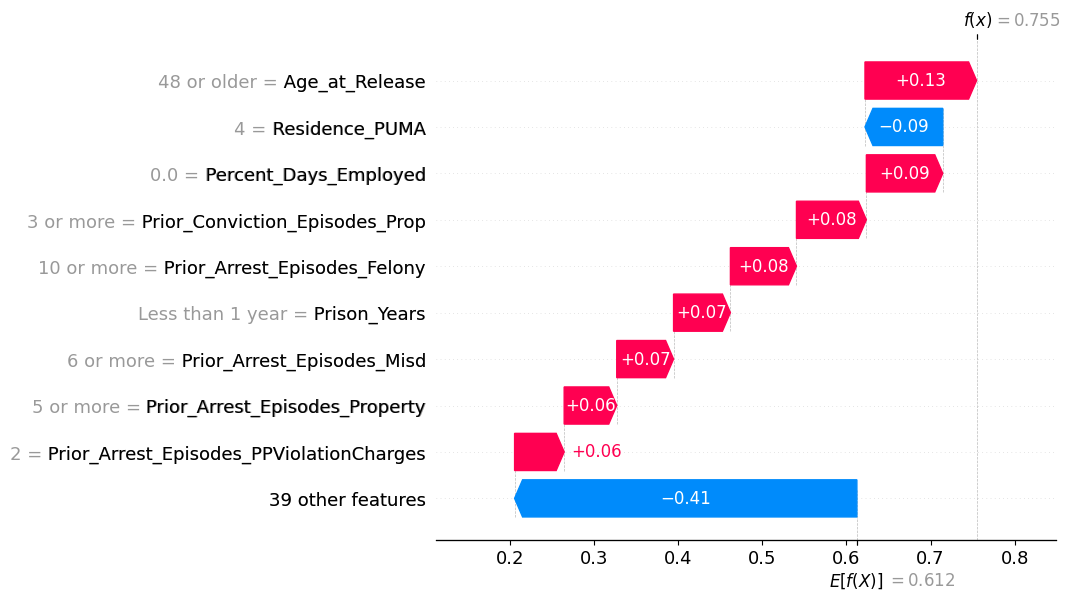

100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


,changes_text
0,Avg_Days_per_DrugTest: nan -> 618.8; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 1.0
1,Supervision_Risk_Score_First: 2.0 -> 7.2; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 1.1
2,Program_Attendances: 0 -> 2; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 1.0
3,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 0.8; Employment_Exempt: False -> True
4,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 1.1; Jobs_Per_Year: 0.0 -> 5.9


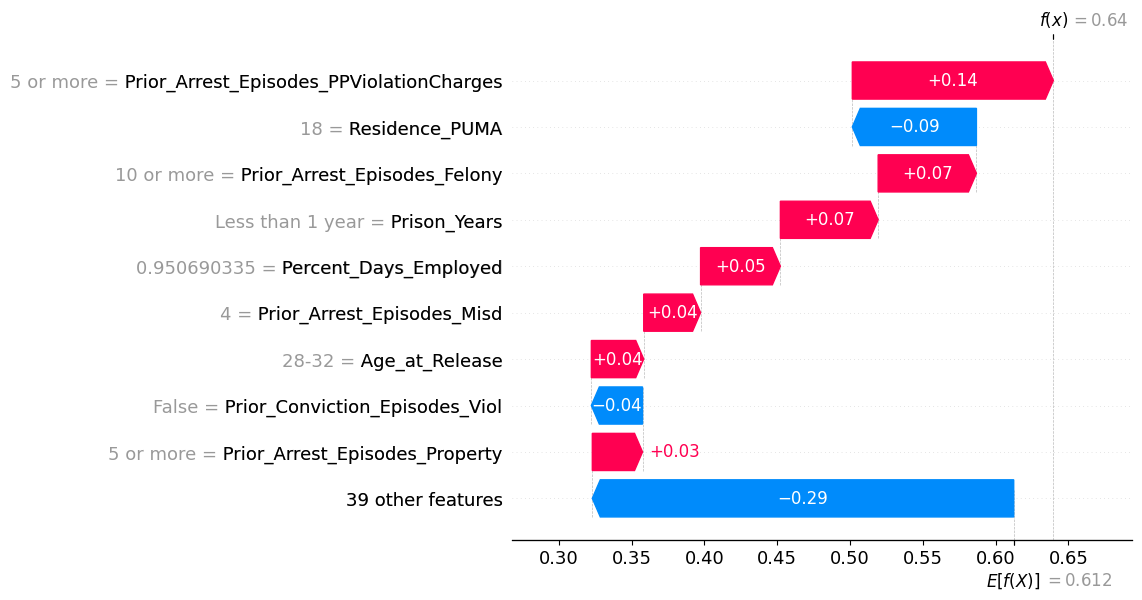

100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


,changes_text
0,Supervision_Risk_Score_First: nan -> 4.3; Condition_MH_SA: False -> True; Jobs_Per_Year: 1.440828402 -> 0.2
1,Supervision_Risk_Score_First: nan -> 1.9; Jobs_Per_Year: 1.440828402 -> 0.6
2,Supervision_Risk_Score_First: nan -> 3.4; Condition_MH_SA: False -> True; Violations_FailToReport: False -> True; Jobs_Per_Year: 1.440828402 -> 0.3
3,Supervision_Risk_Score_First: nan -> 1.9; Violations_MoveWithoutPermission: False -> True; Jobs_Per_Year: 1.440828402 -> 0.6
4,Supervision_Risk_Score_First: nan -> 6.0; Condition_MH_SA: False -> True; Violations_FailToReport: False -> True; Avg_Days_per_DrugTest: 101.4 -> 446.8; Jobs_Per_Year: 1.440828402 -> 0.6


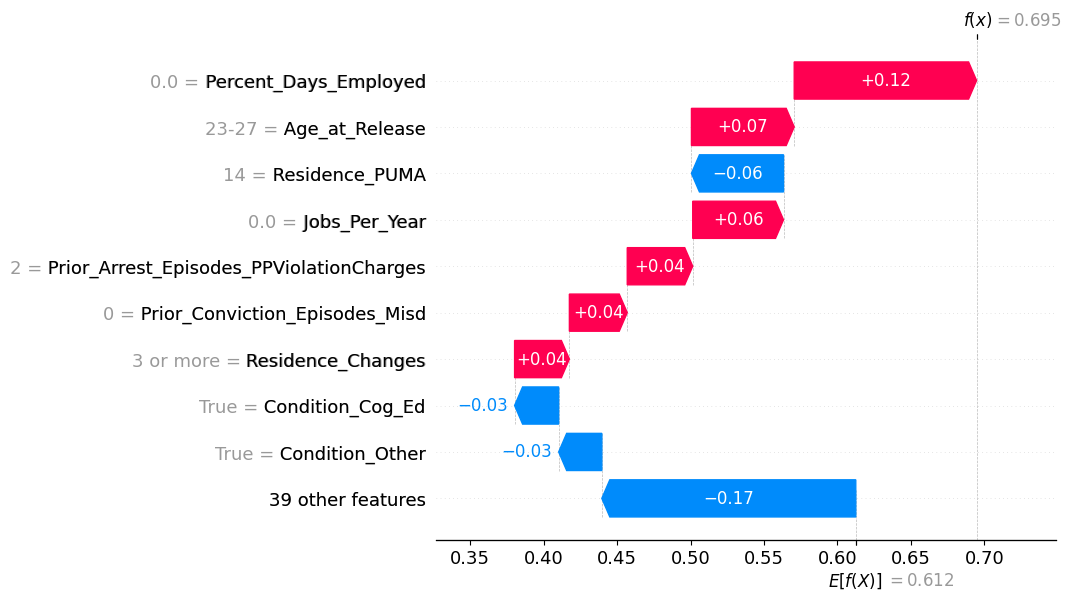

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


,changes_text
0,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 1.0
1,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 0.7; Employment_Exempt: False -> True
2,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.2; Percent_Days_Employed: 0.0 -> 0.7
3,Avg_Days_per_DrugTest: nan -> 374.1; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 0.9
4,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.0 -> 0.9


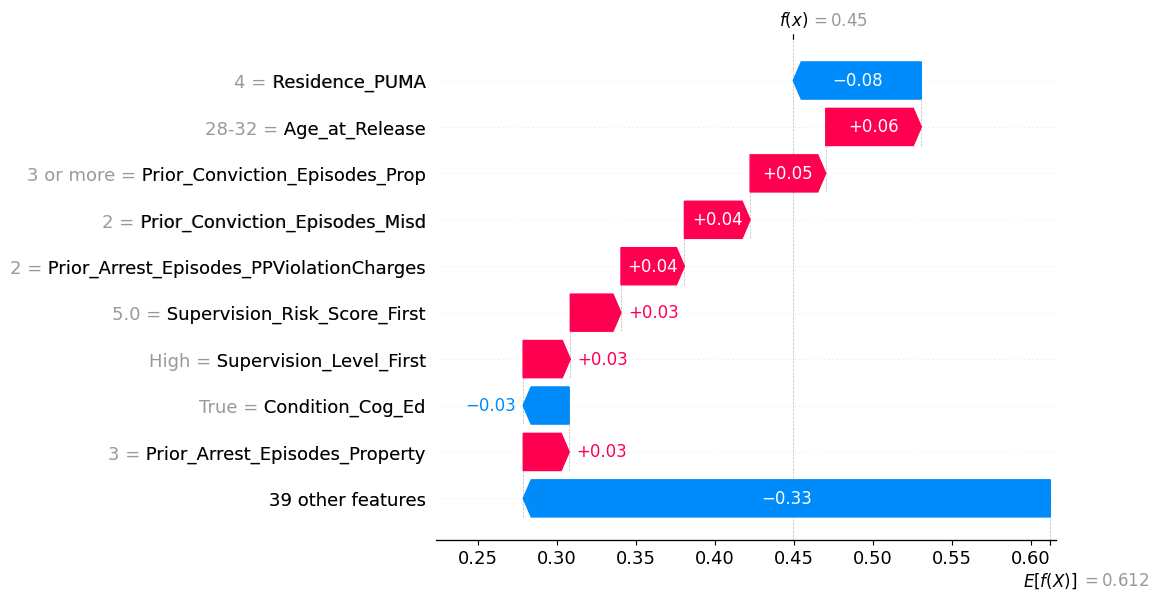

100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


,changes_text
0,Supervision_Level_First: High -> Standard; Education_Level: High School Diploma -> Less than HS diploma
1,Supervision_Level_First: High -> Specialized; Dependents: 2 -> 1
2,Supervision_Level_First: High -> Standard; Employment_Exempt: False -> True
3,Avg_Days_per_DrugTest: 74.06666667 -> 428.8
4,Violations_FailToReport: False -> True; DrugTests_Cocaine_Positive: 0.0 -> 0.5


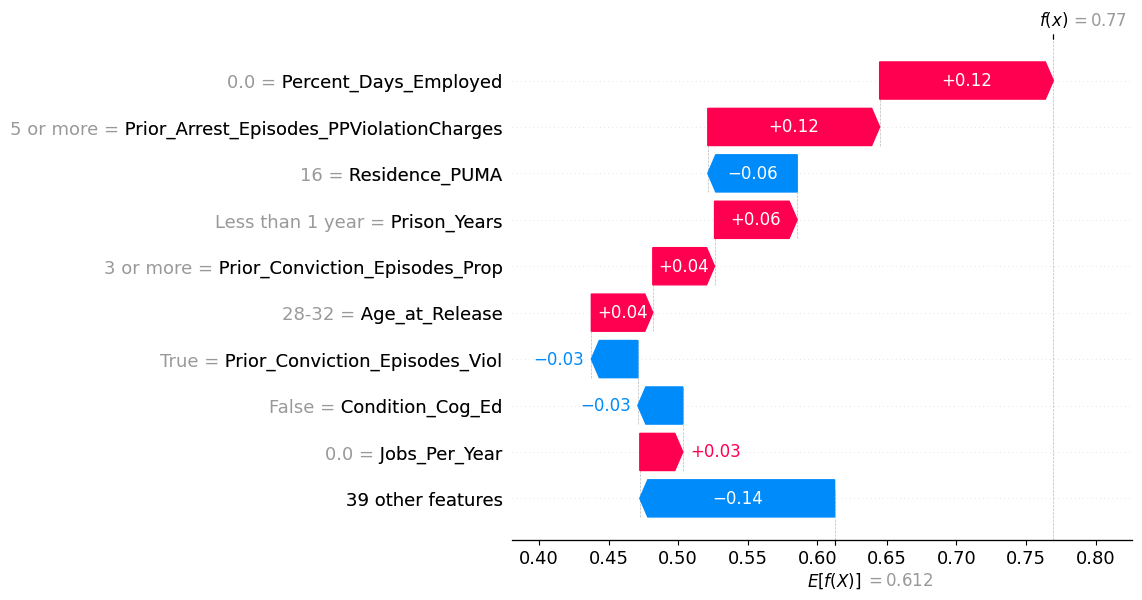

100%|██████████| 1/1 [00:02<00:00,  2.26s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 02 sec
diCE constrained CF generation failed: No counterfactuals found for any of the query points! Kindly check your configuration.


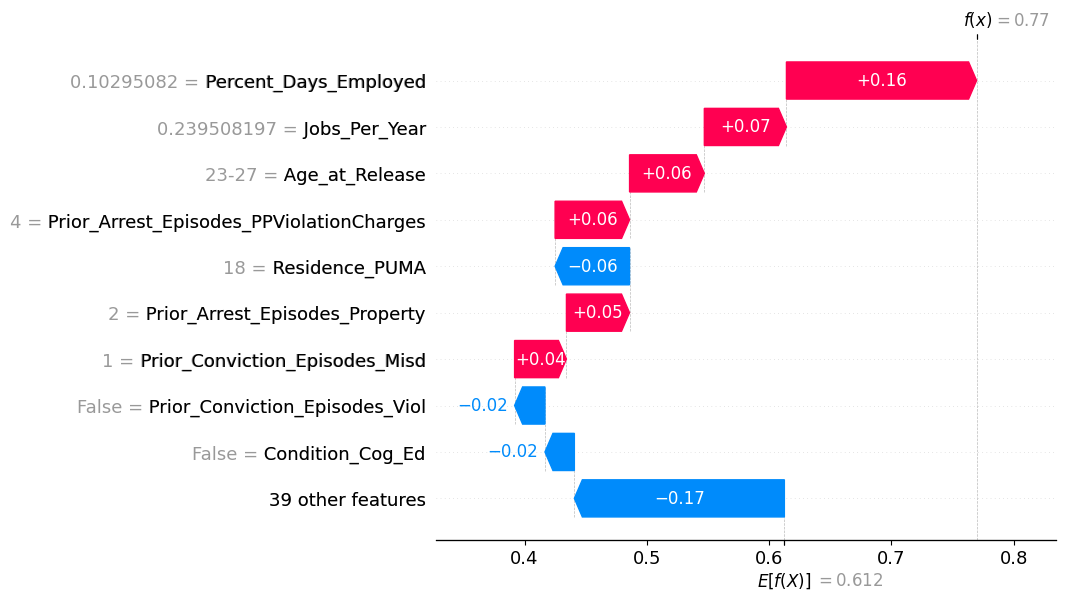

100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


,changes_text
0,Avg_Days_per_DrugTest: nan -> 175.0; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.10295082 -> 1.1
1,Gang_Affiliated: True -> nan; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.10295082 -> 1.0
2,Supervision_Risk_Score_First: 6.0 -> 3.9; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.10295082 -> 1.1
3,Delinquency_Reports: 0 -> 4 or more; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.10295082 -> 0.9
4,Supervision_Risk_Score_First: 6.0 -> 2.6; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.10295082 -> 1.0


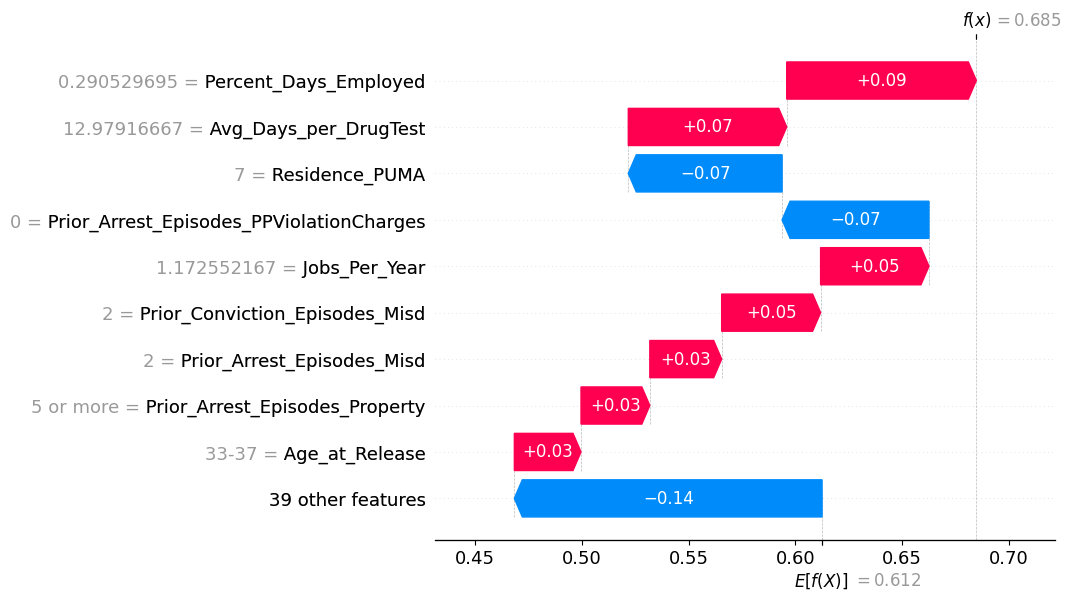

100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


,changes_text
0,Supervision_Risk_Score_First: 6.0 -> 2.7; Avg_Days_per_DrugTest: 12.97916667 -> 146.1
1,DrugTests_Meth_Positive: 0.083333336 -> 0.0; Percent_Days_Employed: 0.290529695 -> 0.8; Employment_Exempt: False -> True
2,Supervision_Risk_Score_First: 6.0 -> 1.7; DrugTests_Other_Positive: 0.0 -> 0.1; Employment_Exempt: False -> True
3,Residence_PUMA: 7 -> 8; Supervision_Risk_Score_First: 6.0 -> 1.4; Education_Level: Less than HS diploma -> At least some college; Employment_Exempt: False -> True
4,Supervision_Risk_Score_First: 6.0 -> 2.0; DrugTests_Other_Positive: 0.0 -> 0.1; Employment_Exempt: False -> True


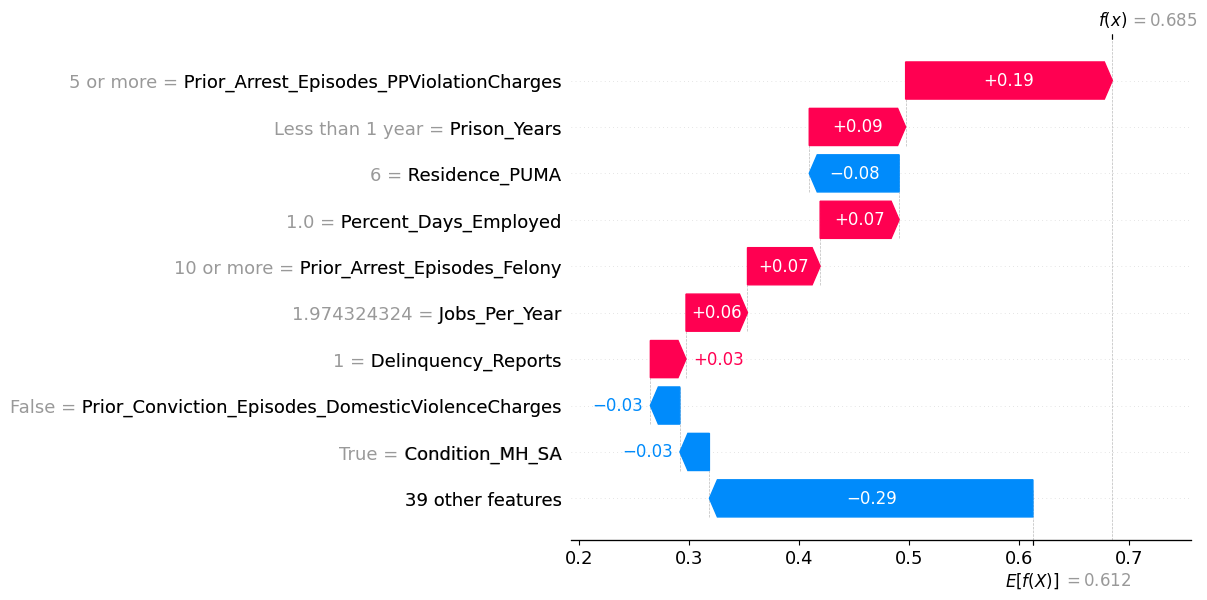

100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


,changes_text
0,Prison_Offense: nan -> Property; Jobs_Per_Year: 1.974324324 -> 0.2
1,Prison_Offense: nan -> Property; Violations_MoveWithoutPermission: False -> True; Jobs_Per_Year: 1.974324324 -> 0.4
2,Prison_Offense: nan -> Property; Violations_MoveWithoutPermission: False -> True; Avg_Days_per_DrugTest: 74.0 -> 269.9; Jobs_Per_Year: 1.974324324 -> 0.4
3,Prison_Offense: nan -> Property; Condition_Other: False -> True; Program_UnexcusedAbsences: 0 -> 3 or more; Jobs_Per_Year: 1.974324324 -> 0.0
4,Dependents: 3 or more -> 1; Prison_Offense: nan -> Property; DrugTests_THC_Positive: 0.0 -> 0.9; Jobs_Per_Year: 1.974324324 -> 0.3


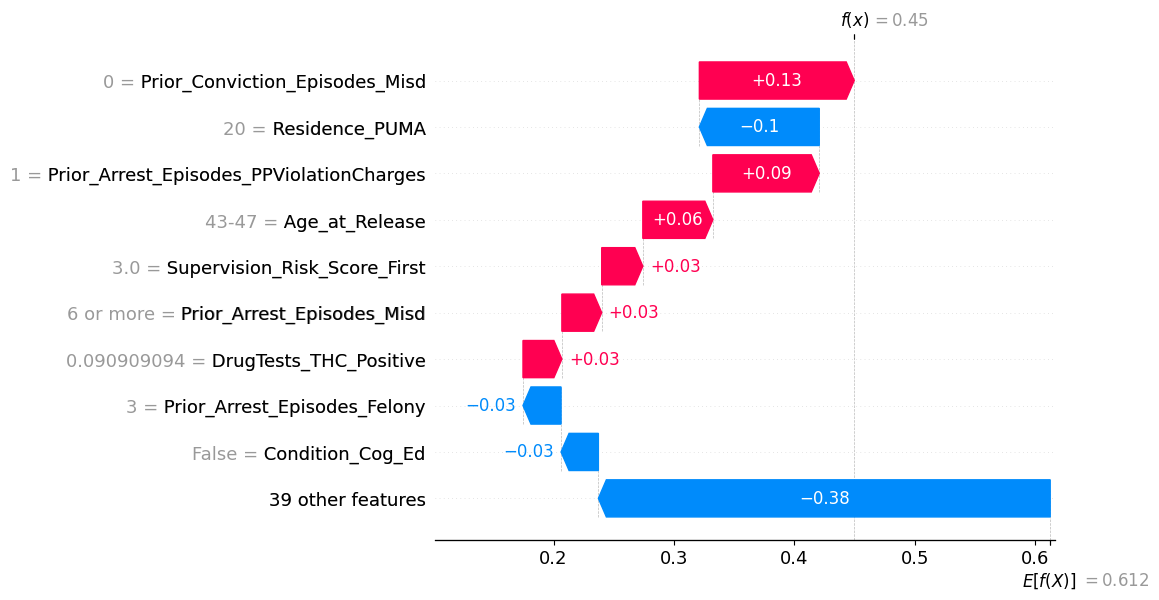

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


,changes_text
0,Program_Attendances: 0 -> 1; Percent_Days_Employed: 0.983412322 -> 0.4
1,Violations_Instruction: False -> True; Percent_Days_Employed: 0.983412322 -> 0.4
2,Condition_Other: False -> True; DrugTests_Meth_Positive: 0.0 -> 0.3
3,Residence_PUMA: 20 -> 6; Percent_Days_Employed: 0.983412322 -> 0.3
4,Violations_FailToReport: False -> True; Percent_Days_Employed: 0.983412322 -> 0.0


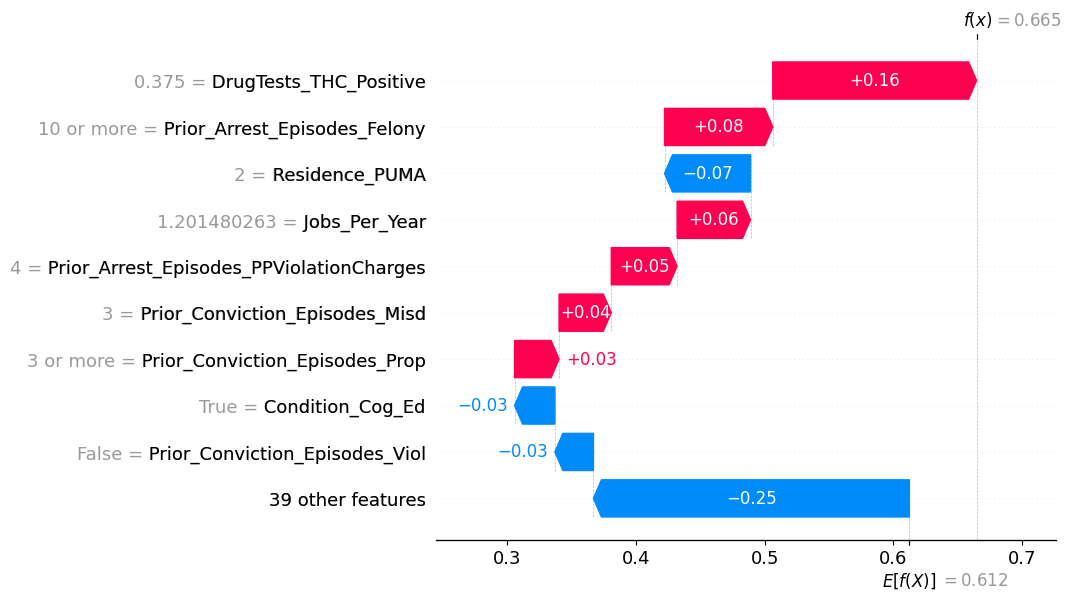

100%|██████████| 1/1 [00:02<00:00,  2.94s/it]


,changes_text
0,Violations_FailToReport: False -> True; Program_UnexcusedAbsences: 3 or more -> 2; Avg_Days_per_DrugTest: 76.0 -> 869.7; DrugTests_THC_Positive: 0.375 -> 0.1; Jobs_Per_Year: 1.201480263 -> 0.3; Employment_Exempt: False -> True
1,Residence_PUMA: 2 -> 10; Supervision_Risk_Score_First: 10.0 -> 3.2; Education_Level: High School Diploma -> Less than HS diploma; DrugTests_THC_Positive: 0.375 -> 0.0; DrugTests_Other_Positive: 0.0 -> 0.6; Employment_Exempt: False -> True
2,Residence_PUMA: 2 -> 25; Avg_Days_per_DrugTest: 76.0 -> 33.0; DrugTests_THC_Positive: 0.375 -> 0.0; DrugTests_Other_Positive: 0.0 -> 0.4; Jobs_Per_Year: 1.201480263 -> 0.6
3,Residence_PUMA: 2 -> 19; Supervision_Risk_Score_First: 10.0 -> 9.2; Education_Level: High School Diploma -> At least some college; Dependents: 2 -> 3 or more; Violations_ElectronicMonitoring: False -> True; Violations_Instruction: False -> True; Violations_FailToReport: False -> True; Residence_Changes: 1 -> 3 or more; DrugTests_THC_Positive: 0.375 -> 0.1; Percent_Days_Employed: 0.766447368 -> 0.7; Jobs_Per_Year: 1.201480263 -> 0.4
4,Residence_PUMA: 2 -> 19; Supervision_Risk_Score_First: 10.0 -> 9.2; Education_Level: High School Diploma -> At least some college; Dependents: 2 -> 3 or more; Violations_ElectronicMonitoring: False -> True; Violations_Instruction: False -> True; Violations_FailToReport: False -> True; Delinquency_Reports: 4 or more -> 0; Residence_Changes: 1 -> 3 or more; DrugTests_THC_Positive: 0.375 -> 0.1; Percent_Days_Employed: 0.766447368 -> 0.7; Jobs_Per_Year: 1.201480263 -> 0.4


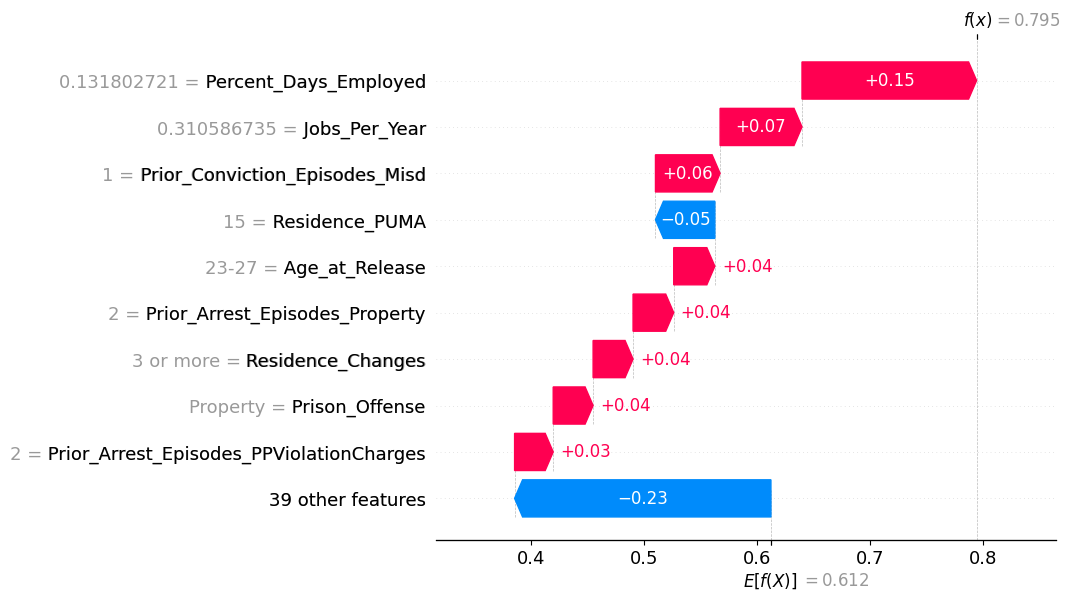

100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


,changes_text
0,Gang_Affiliated: True -> nan; Education_Level: Less than HS diploma -> At least some college; Violations_Instruction: False -> True; Residence_Changes: 3 or more -> 0; Percent_Days_Employed: 0.131802721 -> 0.8; Employment_Exempt: False -> True
1,Residence_PUMA: 15 -> 11; Gang_Affiliated: True -> True; Violations_Instruction: False -> True; Delinquency_Reports: 0 -> 4 or more; Program_UnexcusedAbsences: 0 -> 2; Residence_Changes: 3 or more -> 0; DrugTests_Cocaine_Positive: 0.0 -> 0.5; Percent_Days_Employed: 0.131802721 -> 1.0
2,Gang_Affiliated: True -> True; Supervision_Risk_Score_First: 9.0 -> 1.7; Supervision_Level_First: Specialized -> Standard; Violations_Instruction: False -> True; Violations_FailToReport: False -> True; Percent_Days_Employed: 0.131802721 -> 1.0; Employment_Exempt: False -> True
3,Gang_Affiliated: True -> nan; Supervision_Risk_Score_First: 9.0 -> 3.4; Supervision_Level_First: Specialized -> High; Violations_Instruction: False -> True; Delinquency_Reports: 0 -> 4 or more; Percent_Days_Employed: 0.131802721 -> 0.7
4,Gang_Affiliated: True -> False; Supervision_Risk_Score_First: 9.0 -> 2.9; Dependents: 3 or more -> 1; Violations_Instruction: False -> True; Violations_FailToReport: False -> True; Avg_Days_per_DrugTest: 130.6666667 -> 403.6; Percent_Days_Employed: 0.131802721 -> 1.0


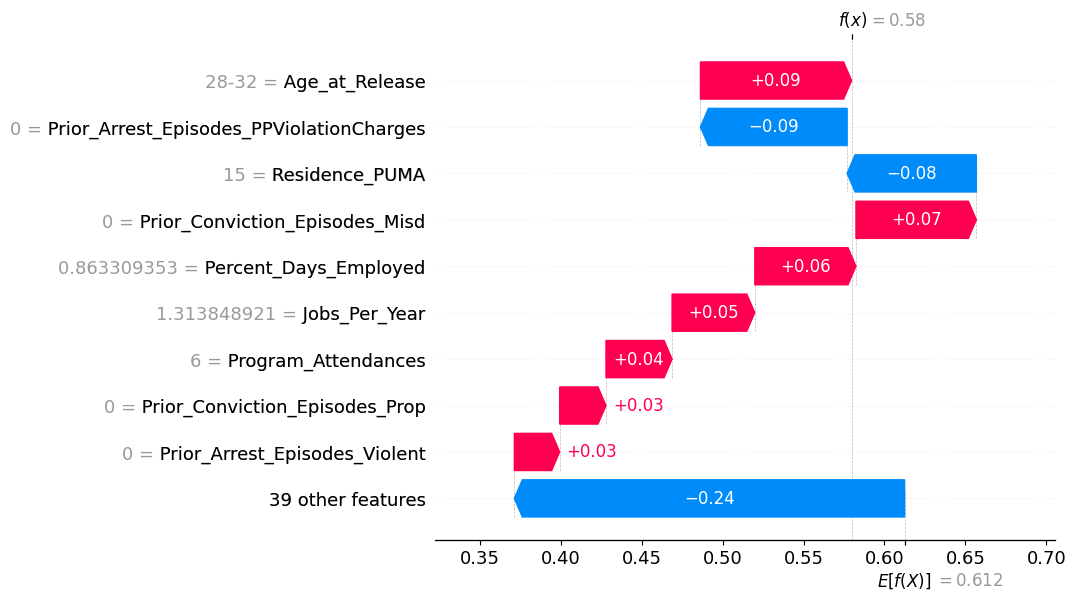

100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


,changes_text
0,Dependents: 0 -> 1; Prison_Offense: nan -> Property; Program_Attendances: 6 -> 1
1,Prison_Offense: nan -> Property; Delinquency_Reports: 0 -> 4 or more; DrugTests_Meth_Positive: 0.0 -> 1.1
2,Prison_Offense: nan -> Property; DrugTests_THC_Positive: 0.0 -> 0.1; DrugTests_Other_Positive: 0.071428575 -> 0.5
3,Gang_Affiliated: False -> True; Prison_Offense: nan -> Property
4,Prison_Offense: nan -> Property; DrugTests_Meth_Positive: 0.0 -> 0.6


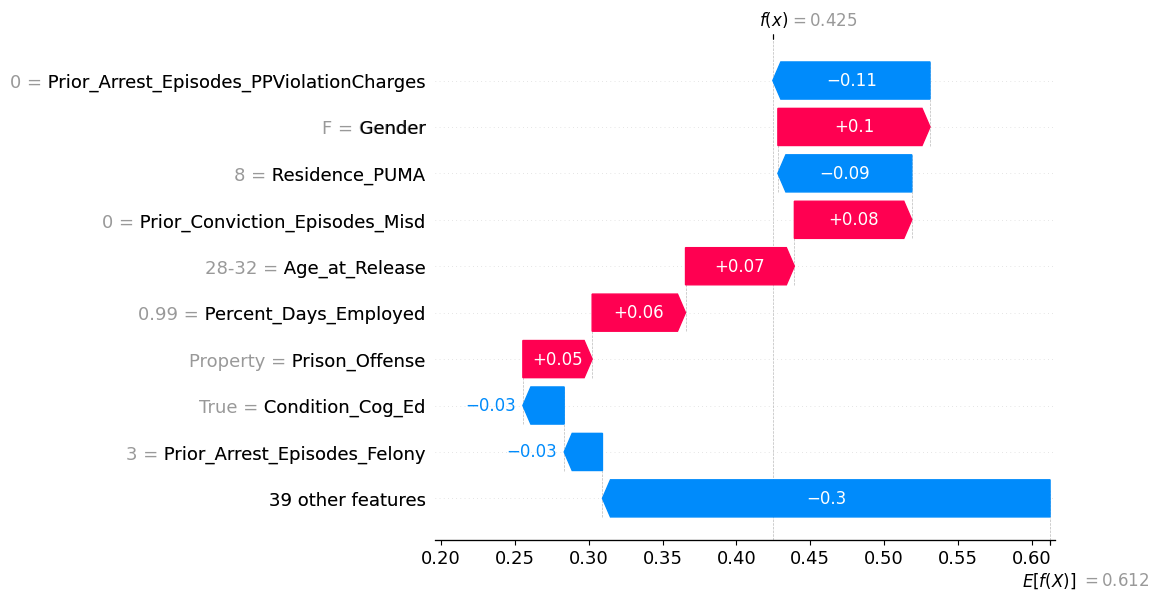

100%|██████████| 1/1 [00:02<00:00,  2.58s/it]


,changes_text
0,Gang_Affiliated: nan -> False; Supervision_Risk_Score_First: 5.0 -> 8.1; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.99 -> 0.3
1,Gang_Affiliated: nan -> False; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.99 -> 0.3
2,Gang_Affiliated: nan -> False; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.99 -> 0.1
3,Gang_Affiliated: nan -> nan; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.99 -> 0.1
4,Gang_Affiliated: nan -> False; Supervision_Level_First: Standard -> Specialized; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 0.99 -> 0.3


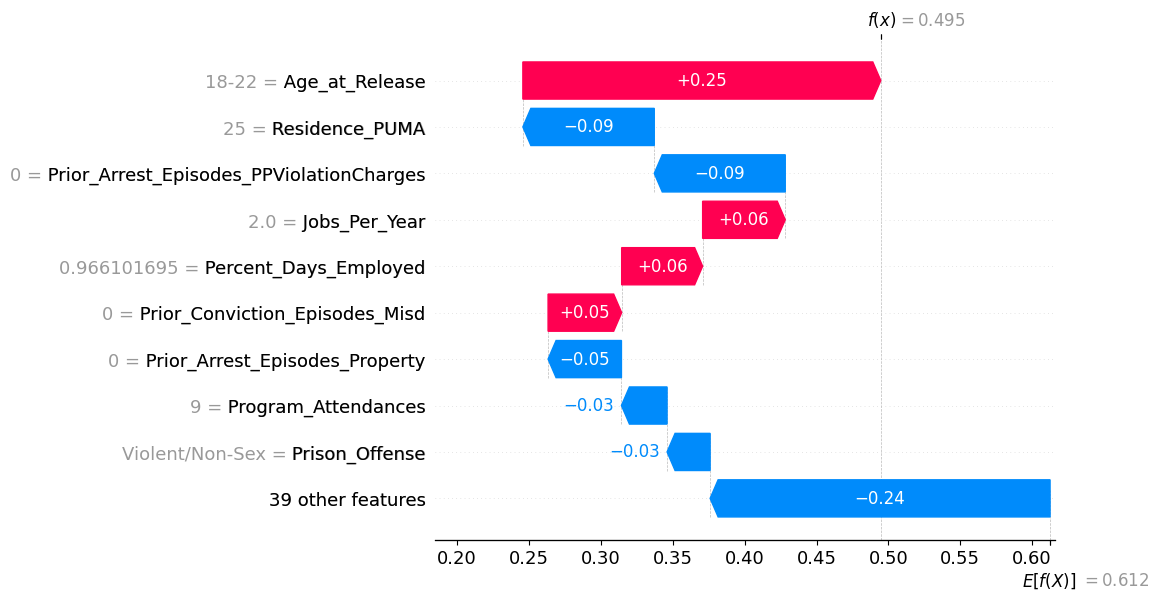

100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


,changes_text
0,DrugTests_THC_Positive: 0.0 -> 0.7; DrugTests_Other_Positive: 0.0 -> 1.0
1,Violations_Instruction: False -> True; DrugTests_THC_Positive: 0.0 -> 0.9
2,Violations_Instruction: False -> True; DrugTests_THC_Positive: 0.0 -> 0.8
3,Violations_ElectronicMonitoring: False -> True; DrugTests_THC_Positive: 0.0 -> 0.3
4,DrugTests_THC_Positive: 0.0 -> 0.6


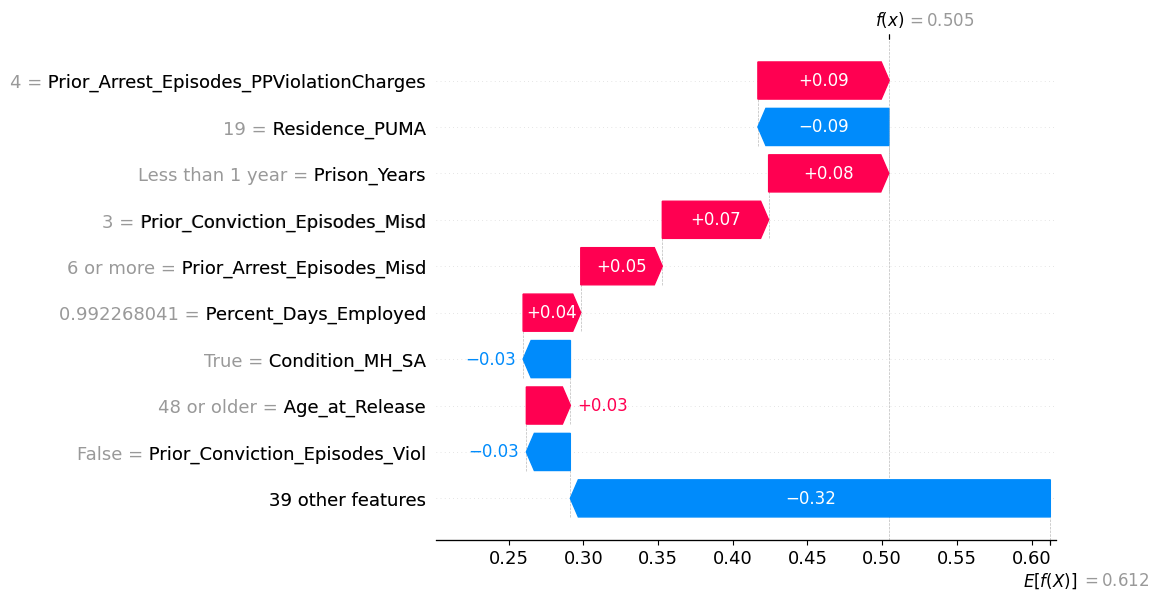

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


,changes_text
0,Violations_MoveWithoutPermission: False -> True; Percent_Days_Employed: 0.992268041 -> 0.5
1,Delinquency_Reports: 0 -> 2; Percent_Days_Employed: 0.992268041 -> 0.1
2,Delinquency_Reports: 0 -> 1; Percent_Days_Employed: 0.992268041 -> 0.8
3,Violations_Instruction: False -> True; Percent_Days_Employed: 0.992268041 -> 0.7
4,Violations_ElectronicMonitoring: False -> True; Percent_Days_Employed: 0.992268041 -> 0.6


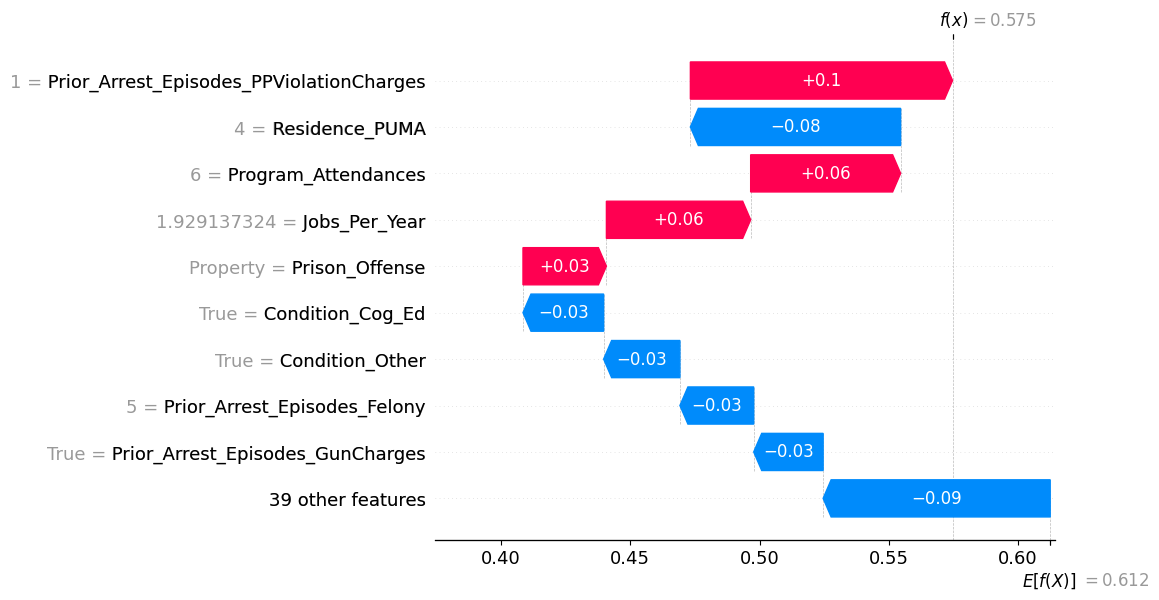

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


,changes_text
0,Dependents: 0 -> 3 or more
1,Condition_MH_SA: False -> True; Avg_Days_per_DrugTest: 33.41176471 -> 418.3
2,Avg_Days_per_DrugTest: 33.41176471 -> 180.7; DrugTests_Other_Positive: 0.0 -> 0.9
3,Residence_PUMA: 4 -> 8; Avg_Days_per_DrugTest: 33.41176471 -> 815.9
4,Condition_MH_SA: False -> True; Violations_MoveWithoutPermission: False -> True


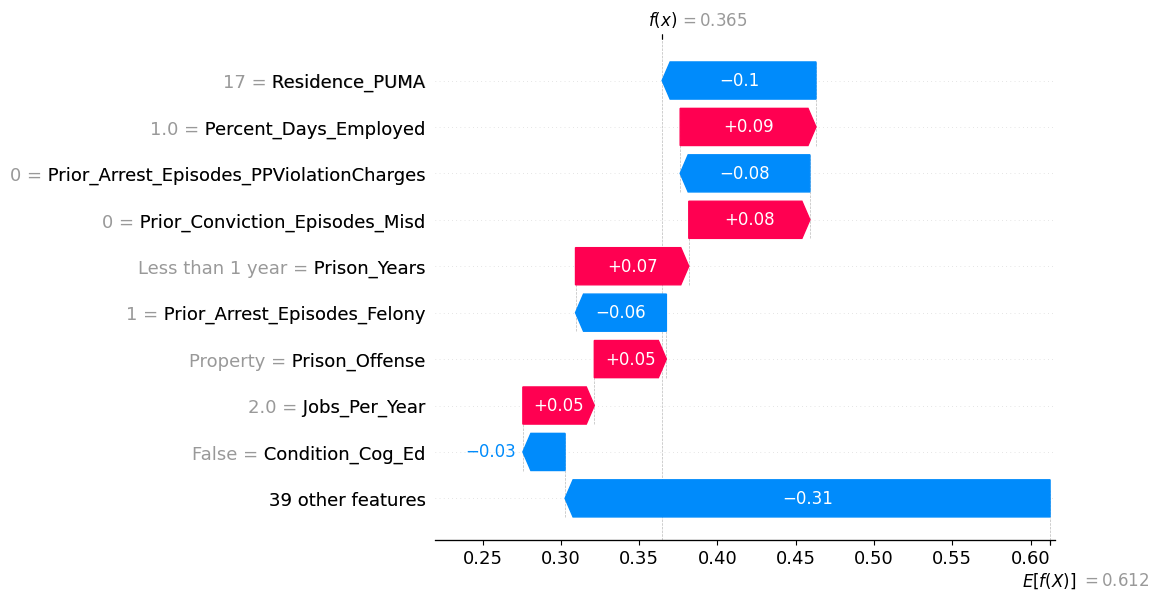

100%|██████████| 1/1 [00:00<00:00,  1.25it/s]


,changes_text
0,Gang_Affiliated: False -> False; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.6; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Employment_Exempt: False -> True
1,Supervision_Risk_Score_First: 2.0 -> 4.8; Delinquency_Reports: 0 -> 1; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 1.0 -> 0.2
2,Education_Level: Less than HS diploma -> At least some college; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.5; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 1.0 -> 0.2
3,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.3; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0; Percent_Days_Employed: 1.0 -> 0.2
4,Gang_Affiliated: False -> True; Program_Attendances: 0 -> 5; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.9; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0


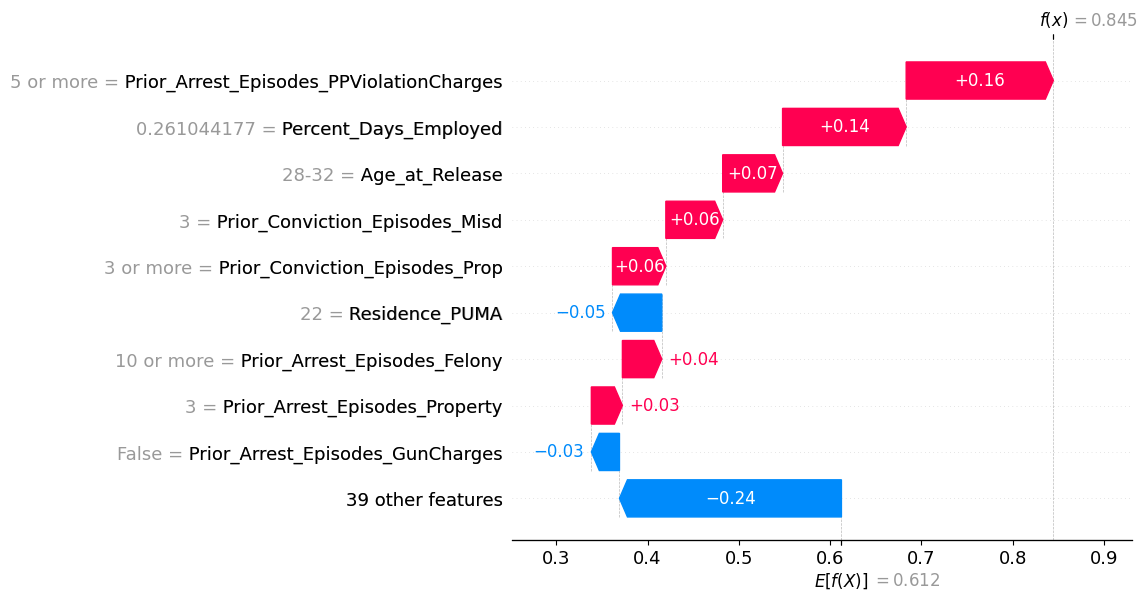

100%|██████████| 1/1 [00:02<00:00,  2.17s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 02 sec
diCE constrained CF generation failed: No counterfactuals found for any of the query points! Kindly check your configuration.


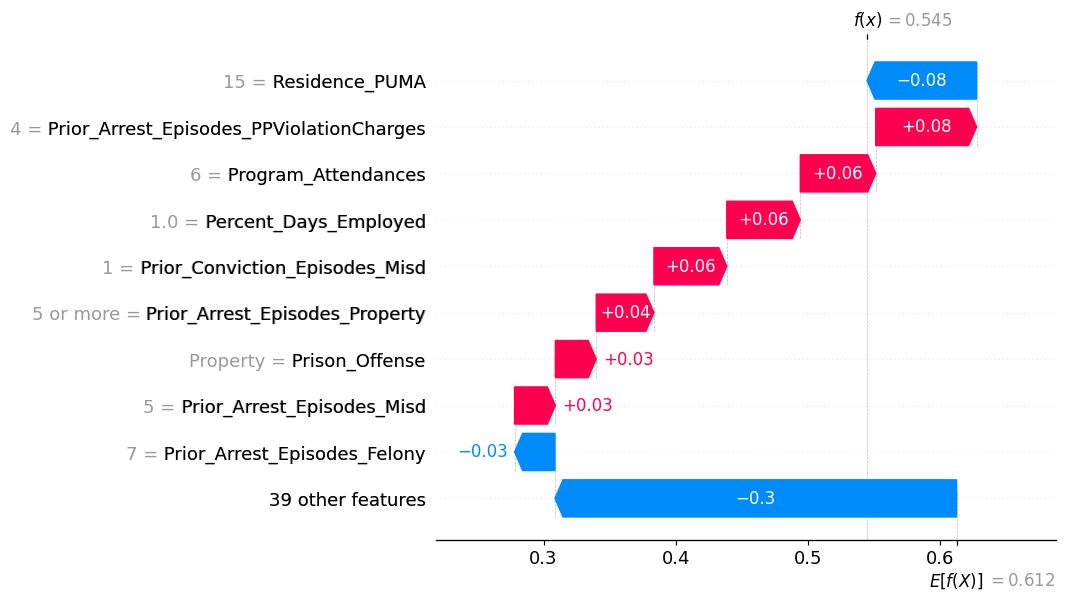

100%|██████████| 1/1 [00:00<00:00,  1.61it/s]


,changes_text
0,Avg_Days_per_DrugTest: 62.5 -> 423.6
1,Supervision_Risk_Score_First: 6.0 -> 4.7
2,Residence_Changes: 3 or more -> 2
3,Supervision_Risk_Score_First: 6.0 -> 3.5
4,Avg_Days_per_DrugTest: 62.5 -> 337.5


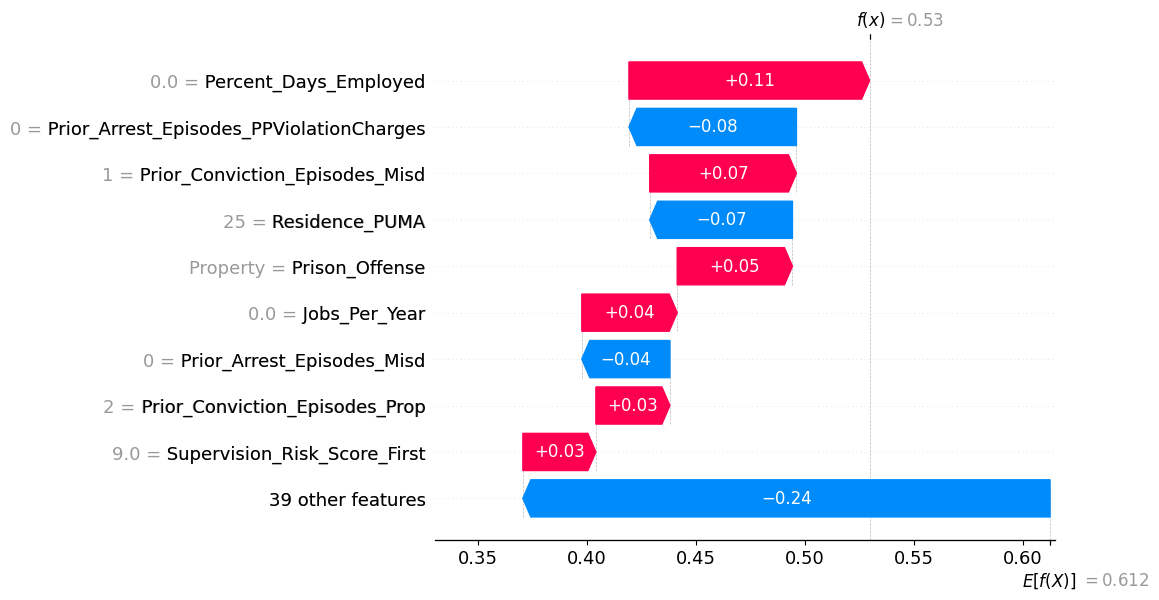

100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


,changes_text
0,Gang_Affiliated: False -> nan; Supervision_Level_First: High -> Standard; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.0; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0
1,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.2; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0
2,Violations_ElectronicMonitoring: False -> True; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.6; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0
3,Violations_ElectronicMonitoring: False -> True; Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.5; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 0.0
4,Avg_Days_per_DrugTest: nan -> 55.5; DrugTests_THC_Positive: nan -> 0.3; DrugTests_Cocaine_Positive: nan -> 0.0; DrugTests_Meth_Positive: nan -> 0.0; DrugTests_Other_Positive: nan -> 1.0


In [ ]:
# Pick random unique indices from sampled_idx to evaluate
rng = random.Random(42)
candidates = list(sampled_idx) if 'sampled_idx' in globals() else list(range(len(X_test)))
pick = rng.sample(candidates, min(20, len(candidates)))

reports = {}
for idx in pick:
    df_cf, changes = qualitative_report_for_index(idx, show_waterfall=True)
    reports[idx] = {'cf_df': df_cf, 'changes_df': changes}